<a href="https://colab.research.google.com/github/debashisdotchatterjee/A-Leakage-Aware-Stackelberg-Inspired-Game/blob/main/A_Leakage_Aware_Stackelberg_Inspired_Game_(Share_with_Adrija)_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Retrieval Code

In [1]:
# Option A: scikit-learn + OpenML
from sklearn.datasets import fetch_openml

bank = fetch_openml(data_id=1461, as_frame=True)   # exact data_id preferred
df = bank.frame.copy()

print(df.head())
print(df.columns)

# Make binary target if needed
if "y" in df.columns:
    df["y"] = (df["y"].astype(str).str.lower() == "yes").astype(int)
else:
    df["y"] = (bank.target.astype(str).str.lower() == "yes").astype(int)

# Leakage-aware deployable model:
if "duration" in df.columns:
    df_model = df.drop(columns=["duration"]).copy()
else:
    df_model = df.copy()

print(df_model.shape)
print(df_model["y"].value_counts(dropna=False))

   V1            V2       V3         V4  V5    V6   V7   V8       V9  V10  \
0  58    management  married   tertiary  no  2143  yes   no  unknown    5   
1  44    technician   single  secondary  no    29  yes   no  unknown    5   
2  33  entrepreneur  married  secondary  no     2  yes  yes  unknown    5   
3  47   blue-collar  married    unknown  no  1506  yes   no  unknown    5   
4  33       unknown   single    unknown  no     1   no   no  unknown    5   

   V11  V12  V13  V14  V15      V16 Class  
0  may  261    1   -1    0  unknown     1  
1  may  151    1   -1    0  unknown     1  
2  may   76    1   -1    0  unknown     1  
3  may   92    1   -1    0  unknown     1  
4  may  198    1   -1    0  unknown     1  
Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'Class'],
      dtype='object')
(45211, 18)
y
0    45211
Name: count, dtype: int64



LOADING DATA
Using existing dataframe `df` from notebook environment.
Initial shape: (45211, 18)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1,0



RENAMING COLUMNS IF NEEDED
Applied rename map: {'V1': 'age', 'V2': 'job', 'V3': 'marital', 'V4': 'education', 'V5': 'default', 'V6': 'balance', 'V7': 'housing', 'V8': 'loan', 'V9': 'contact', 'V10': 'day', 'V11': 'month', 'V12': 'duration', 'V13': 'campaign', 'V14': 'pdays', 'V15': 'previous', 'V16': 'poutcome', 'Class': 'target'}
Columns now:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'target', 'y']

ROBUST TARGET MAPPING
Original target counts: {'1': 39922, '2': 5289}
Mapped binary target counts: {0: 39922, 1: 5289}
Target mapping info: {'method': 'minority-class-as-positive mapping', 'positive_label_assumed': '2', 'reason': "Bank Marketing 'subscription=yes' is usually minority; this fixes common numeric coding issues"}

BASIC CLEANING + FEATURE ENGINEERING
Shape after feature engineering: (45211, 24)


,age,job,marital,education,default,balance,housing,loan,contact,day,...,previous,poutcome,target,y,was_previously_contacted,pdays_clean,balance_nonnegative,log_balance_plus1,campaign_gt1,previous_gt0
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,0,unknown,1,0,0,NaN,2143,7.670429,0,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,0,unknown,1,0,0,NaN,29,3.401197,0,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,0,unknown,1,0,0,NaN,2,1.098612,0,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,0,unknown,1,0,0,NaN,1506,7.317876,0,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,0,unknown,1,0,0,NaN,1,0.693147,0,0



EDA
Missingness summary:


,column,missing_count,missing_pct
19,pdays_clean,36954,81.737
0,age,0,0.000
1,job,0,0.000
2,marital,0,0.000
3,education,0,0.000
4,default,0,0.000
5,balance,0,0.000
6,housing,0,0.000
7,loan,0,0.000
8,contact,0,0.000


Binary target class balance:


,class,count,proportion
0,0,39922,0.883015
1,1,5289,0.116985


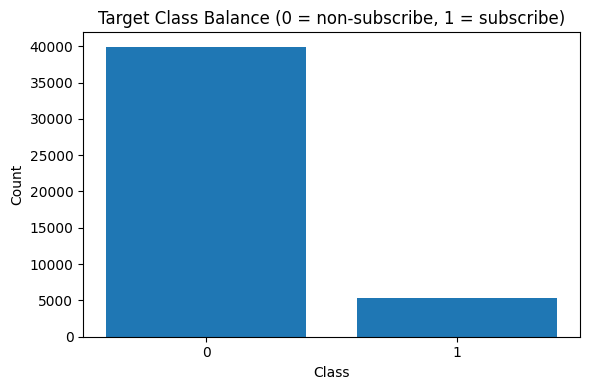

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.000000,39.000000,48.00000,95.000000
balance,45211.0,1362.272058,3044.765829,-8019.0,72.000000,448.000000,1428.00000,102127.000000
day,45211.0,15.806419,8.322476,1.0,8.000000,16.000000,21.00000,31.000000
duration,45211.0,258.163080,257.527812,0.0,103.000000,180.000000,319.00000,4918.000000
campaign,45211.0,2.763841,3.098021,1.0,1.000000,2.000000,3.00000,63.000000
pdays,45211.0,40.197828,100.128746,-1.0,-1.000000,-1.000000,-1.00000,871.000000
previous,45211.0,0.580323,2.303441,0.0,0.000000,0.000000,0.00000,275.000000
y,45211.0,0.116985,0.321406,0.0,0.000000,0.000000,0.00000,1.000000
was_previously_contacted,45211.0,0.182633,0.386369,0.0,0.000000,0.000000,0.00000,1.000000
pdays_clean,8257.0,224.577692,115.344035,1.0,133.000000,194.000000,327.00000,871.000000


,column,n_unique,top_level,top_count
0,job,12,blue-collar,9732
7,month,12,may,13766
8,poutcome,4,unknown,36959
2,education,4,secondary,23202
1,marital,3,married,27214
6,contact,3,cellular,29285
5,loan,2,no,37967
4,housing,2,yes,25130
3,default,2,no,44396
9,target,2,1,39922


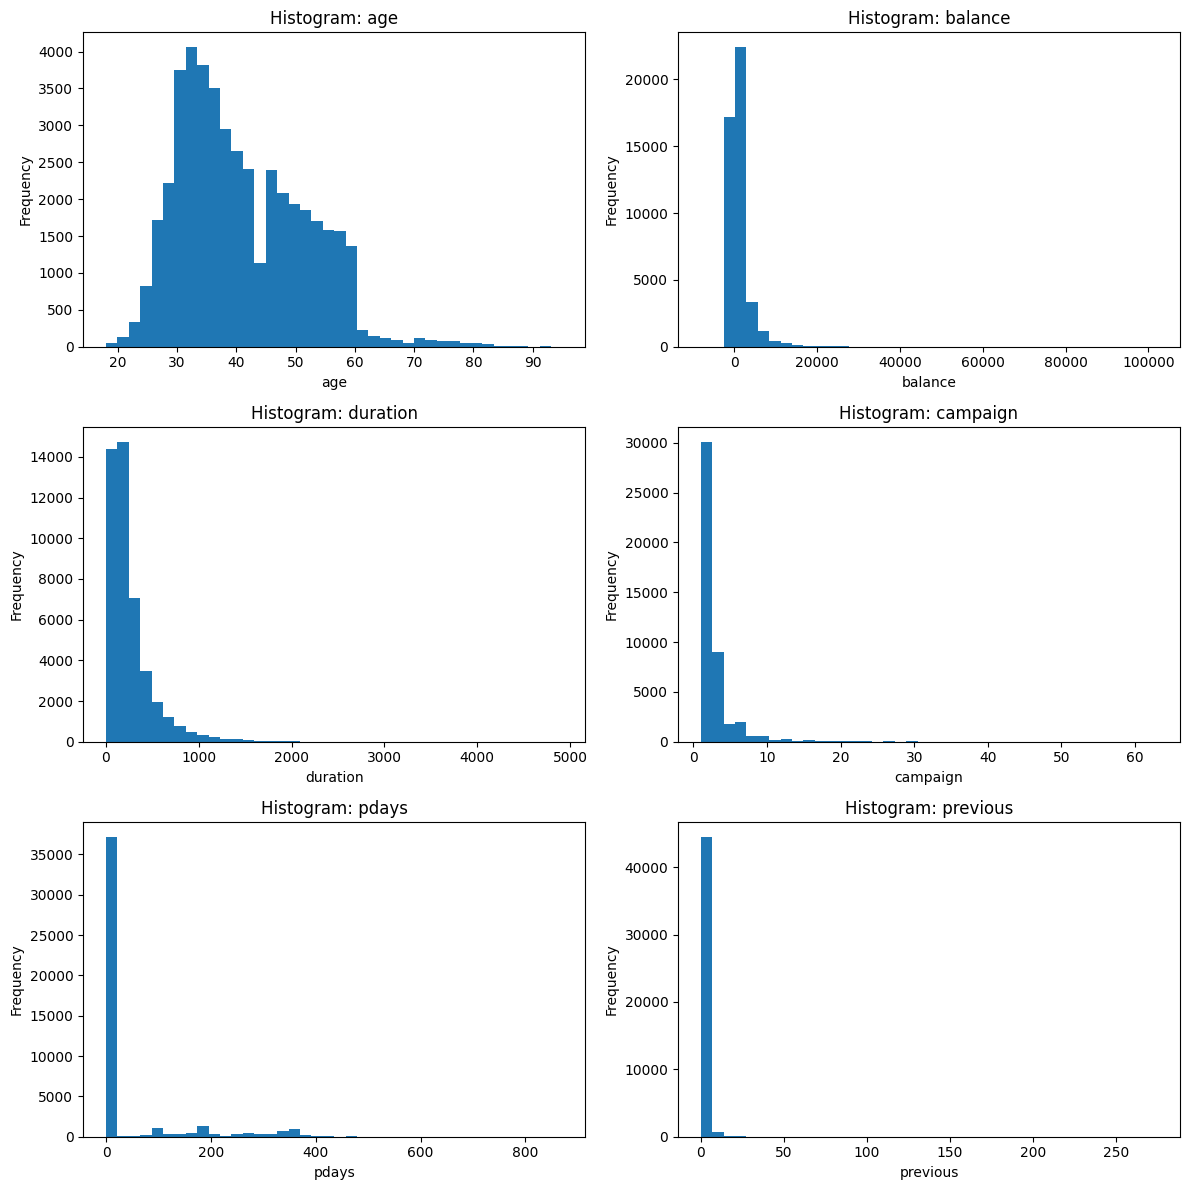

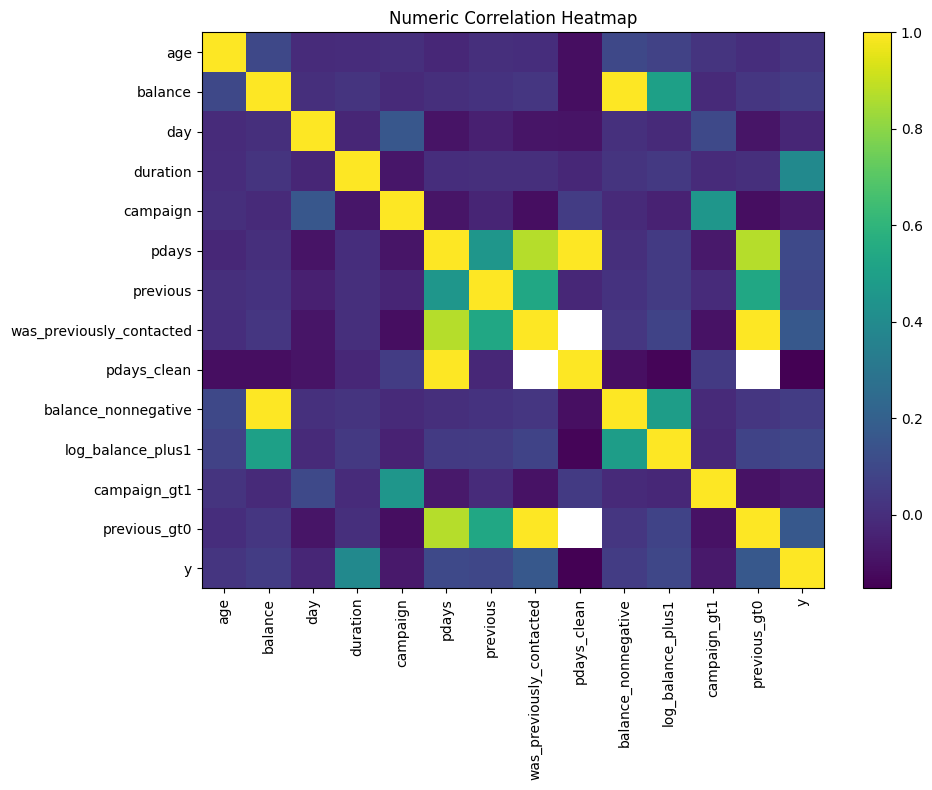

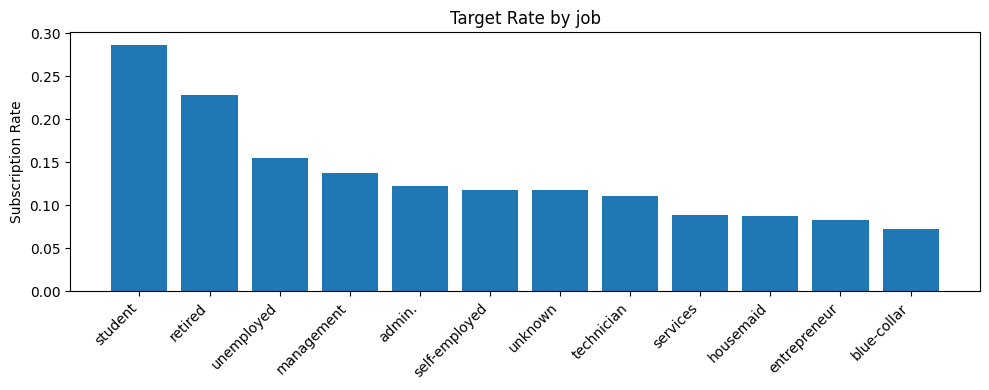

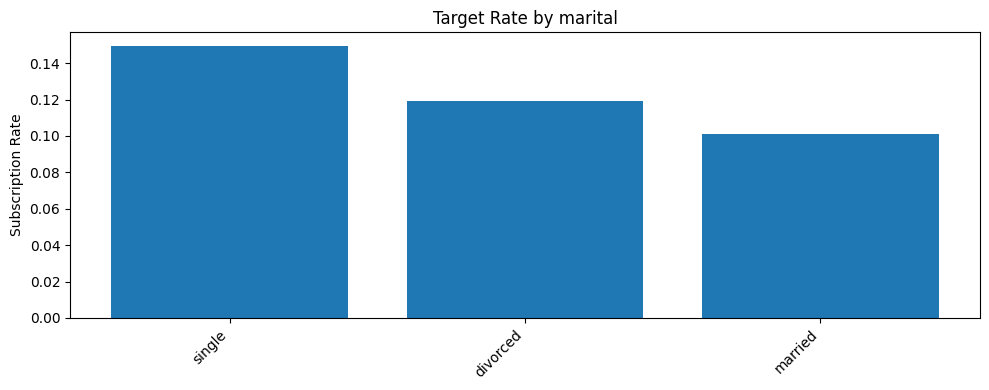

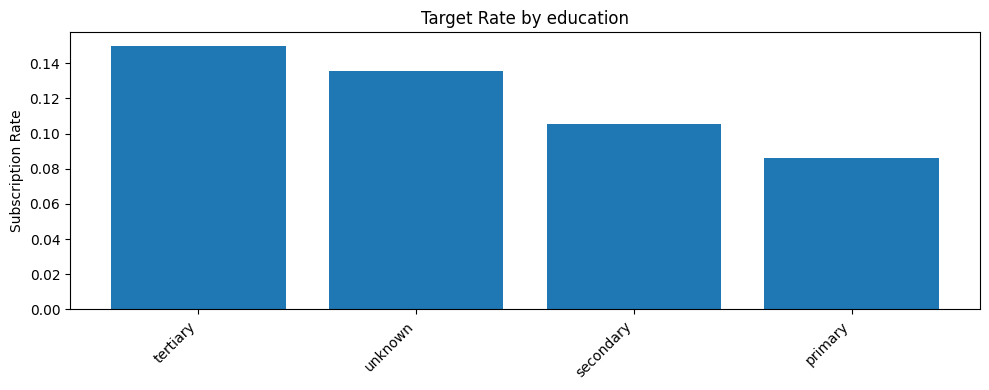

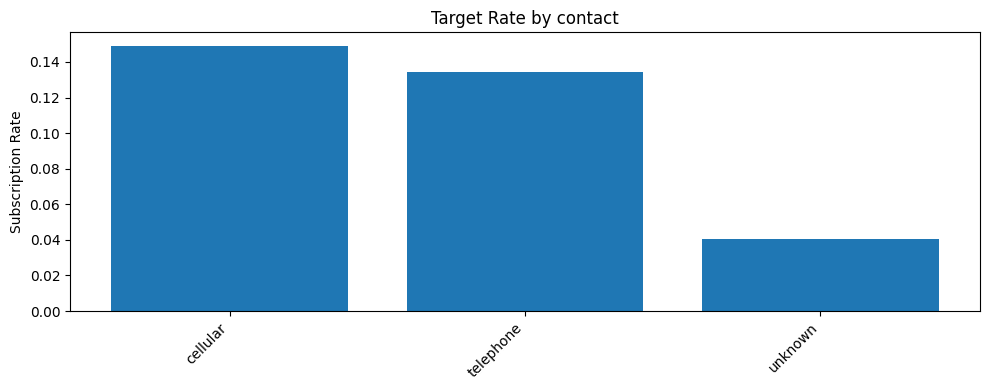

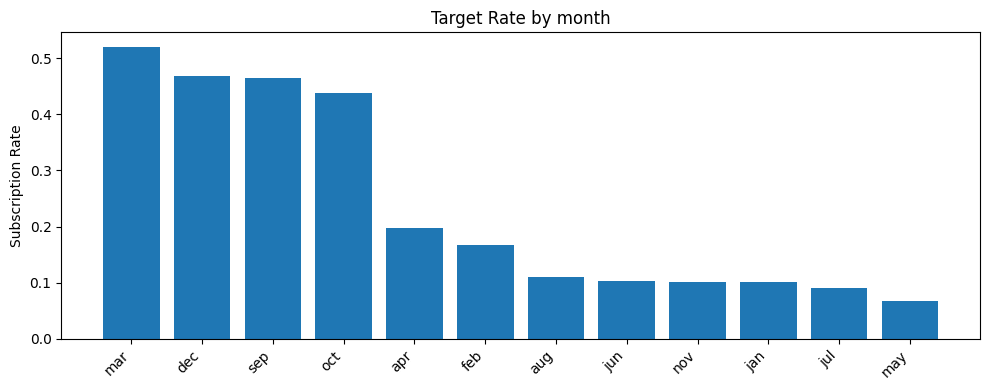

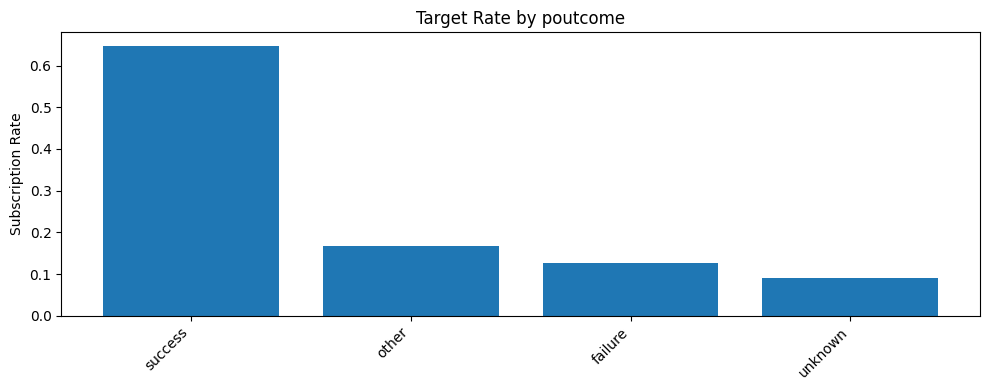

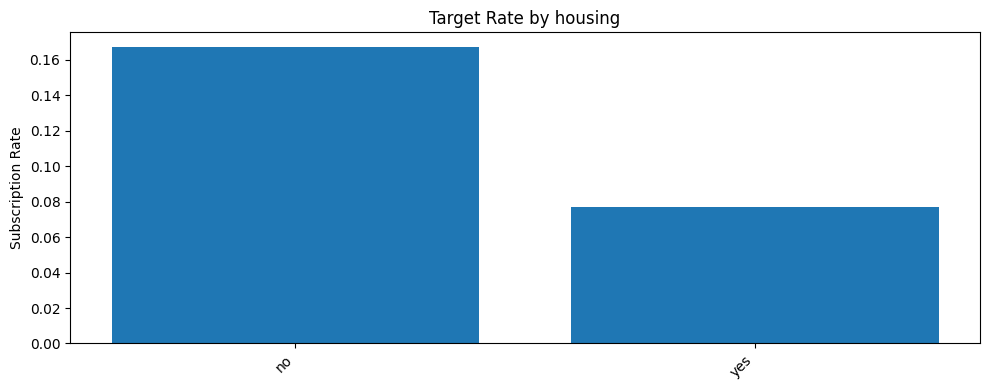

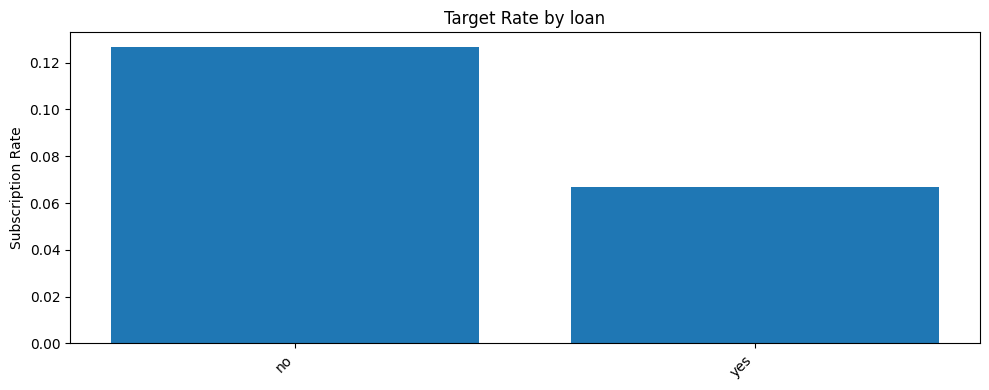


DEPLOYABLE VS LEAKY FEATURE SETS
Deployable features: (45211, 21)
Leaky features (includes duration if present): (45211, 22)

TRAIN / VALID / TEST SPLIT
Train size: 27126
Valid size: 9042
Test size : 9043
{'n_total': 45211, 'n_train': 27126, 'n_valid': 9042, 'n_test': 9043, 'positive_rate_train': 0.11697264616972647, 'positive_rate_valid': 0.11700951117009512, 'positive_rate_test': 0.11699657193409267}

PREPROCESSING

MODEL COMPARISON: DEPLOYABLE FEATURE SET

Training deployable model: Dummy_MostFrequent

Training deployable model: Logistic_L2

Training deployable model: RandomForest

Training deployable model: ExtraTrees

Validation results (deployable):


,valid_Accuracy,valid_Balanced_Accuracy,valid_Precision,valid_Recall,valid_F1,valid_ROC_AUC,valid_PR_AUC,valid_Brier,valid_LogLoss,valid_Threshold,model,best_valid_f1_at_threshold
0,0.869498,0.711691,0.448826,0.505671,0.475556,0.794692,0.455725,0.110869,0.376554,0.50,RandomForest,0.475556
1,0.869608,0.702734,0.447254,0.484877,0.465306,0.784167,0.434967,0.129349,0.422860,0.57,ExtraTrees,0.465306
2,0.876023,0.683818,0.467824,0.432892,0.449681,0.773949,0.412041,0.182539,0.555414,0.66,Logistic_L2,0.449681
3,0.882990,0.500000,0.000000,0.000000,0.000000,0.500000,0.117010,0.117010,2.155395,0.01,Dummy_MostFrequent,0.000000


Best deployable model selected: RandomForest
Validation-chosen threshold: 0.500


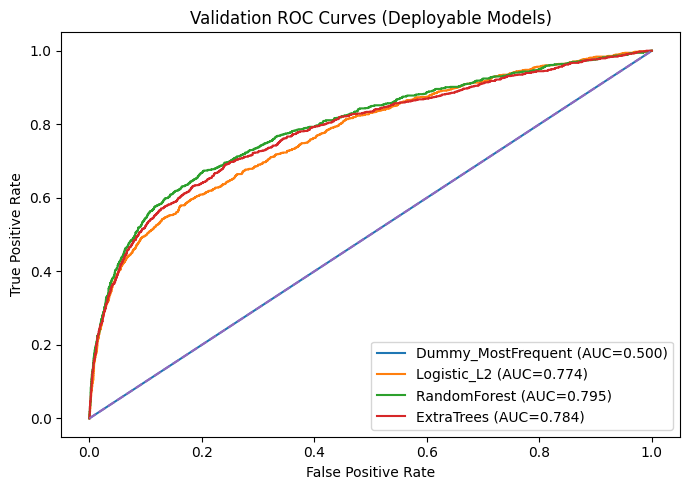

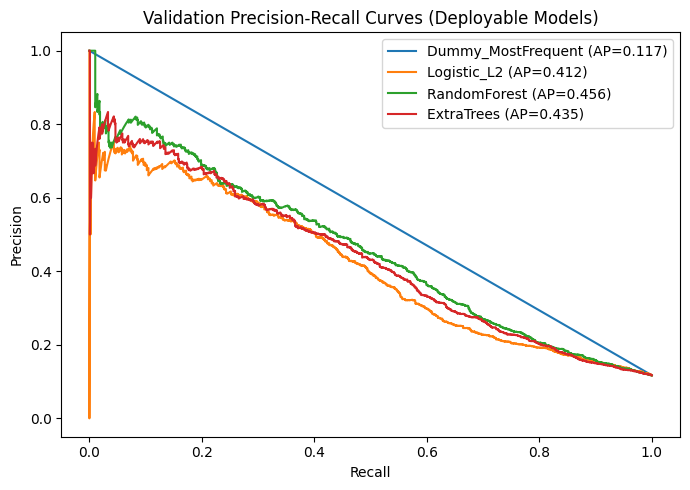


FINAL DEPLOYABLE MODEL (REFIT + CALIBRATION + TEST EVALUATION)
Test metrics for final deployable model:


,test_Accuracy,test_Balanced_Accuracy,test_Precision,test_Recall,test_F1,test_ROC_AUC,test_PR_AUC,test_Brier,test_LogLoss,test_Threshold,model
0,0.895168,0.601592,0.65625,0.218336,0.32766,0.800258,0.453312,0.081782,0.285243,0.5,RandomForest


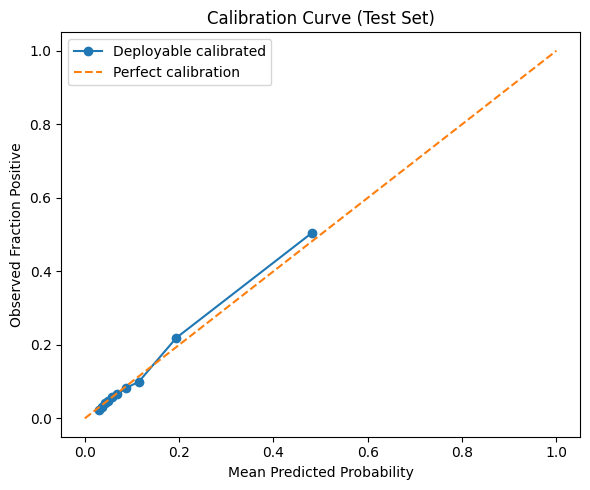

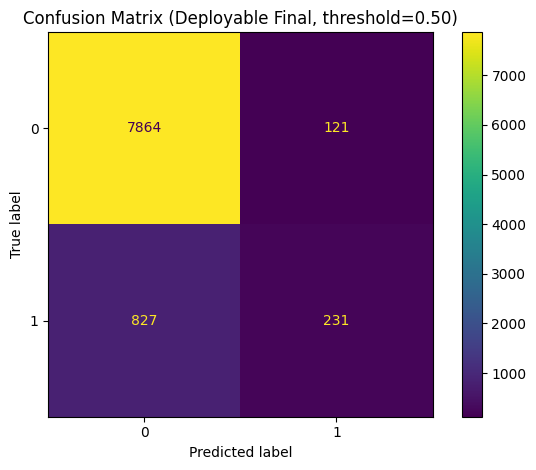


LEAKY BENCHMARK (INCLUDES DURATION)

Training leaky model: Dummy_MostFrequent

Training leaky model: Logistic_L2

Training leaky model: RandomForest

Training leaky model: ExtraTrees
Validation results (leaky benchmark):


,valid_Accuracy,valid_Balanced_Accuracy,valid_Precision,valid_Recall,valid_F1,valid_ROC_AUC,valid_PR_AUC,valid_Brier,valid_LogLoss,valid_Threshold,model,best_valid_f1_at_threshold
0,0.884318,0.839792,0.503654,0.781664,0.612593,0.932086,0.619891,0.080099,0.267553,0.49,RandomForest,0.612593
1,0.872926,0.815303,0.472541,0.740076,0.576796,0.916997,0.575061,0.095075,0.325848,0.48,ExtraTrees,0.576796
2,0.891175,0.796119,0.527448,0.672023,0.591022,0.913957,0.551258,0.118098,0.416335,0.70,Logistic_L2,0.591022
3,0.882990,0.500000,0.000000,0.000000,0.000000,0.500000,0.117010,0.117010,2.155395,0.01,Dummy_MostFrequent,0.000000


Best leaky model selected: RandomForest
Validation-chosen threshold (leaky): 0.490
Deployable vs leaky test comparison:


,setting,test_Accuracy,test_Balanced_Accuracy,test_Precision,test_Recall,test_F1,test_ROC_AUC,test_PR_AUC,test_Brier,test_LogLoss,test_Threshold,model
0,deployable_no_duration,0.895168,0.601592,0.656250,0.218336,0.327660,0.800258,0.453312,0.081782,0.285243,0.50,RandomForest
1,leaky_with_duration,0.906889,0.723021,0.633995,0.482987,0.548283,0.927202,0.614221,0.064581,0.208484,0.49,RandomForest


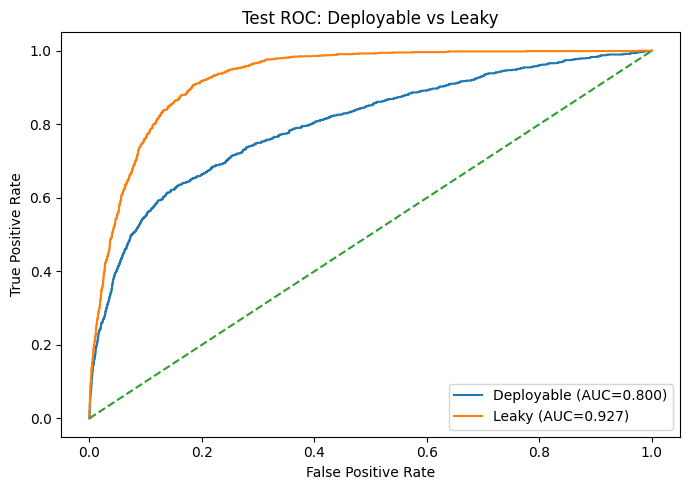

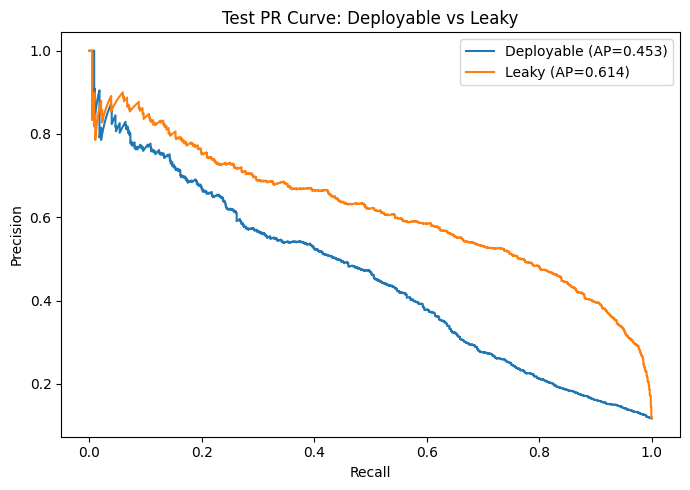


INTERPRETABILITY FOR FINAL DEPLOYABLE MODEL


,feature,importance
0,num__age,0.090546
1,num__balance,0.081359
2,num__day,0.078350
3,num__balance_nonnegative,0.075857
4,num__log_balance_plus1,0.075057
5,cat__poutcome_success,0.049039
6,num__campaign,0.039370
7,cat__contact_unknown,0.038973
8,num__pdays_clean,0.036330
9,num__pdays,0.031948


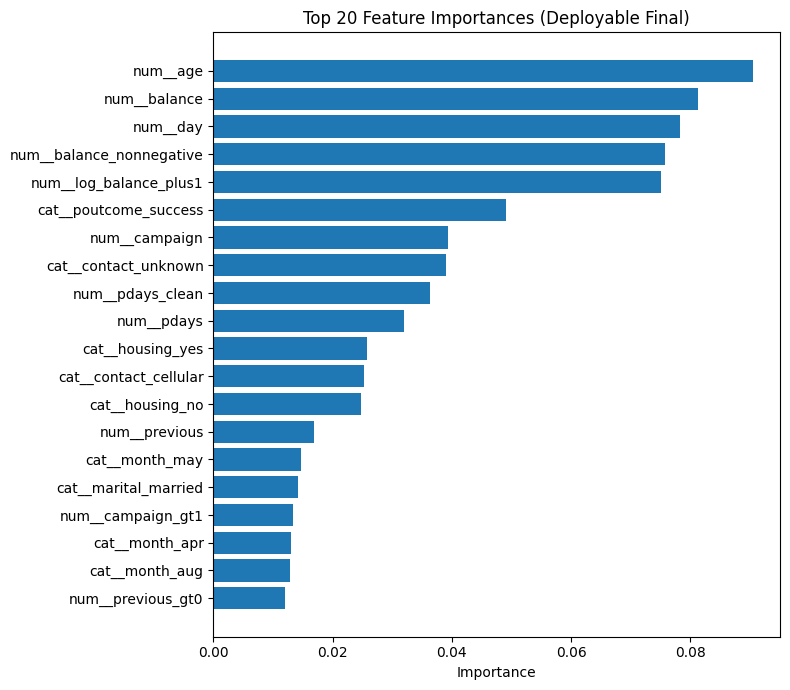


LIFT / DECILE ANALYSIS


,decile,n,responders,avg_score,response_rate,lift,cum_responders,cum_response_share
0,D1,905,457,0.482012,0.504972,4.316130,457,0.431947
1,D2,904,198,0.194026,0.219027,1.872077,655,0.619093
2,D3,904,90,0.114369,0.099558,0.850944,745,0.704159
3,D4,904,74,0.086245,0.081858,0.699665,819,0.774102
4,D5,905,59,0.069035,0.065193,0.557225,878,0.829868
5,D6,904,52,0.057511,0.057522,0.491656,930,0.879017
6,D7,904,42,0.049226,0.046460,0.397107,972,0.918715
7,D8,904,38,0.042659,0.042035,0.359287,1010,0.954631
8,D9,904,27,0.037062,0.029867,0.255283,1037,0.980151
9,D10,905,21,0.030586,0.023204,0.198334,1058,1.000000


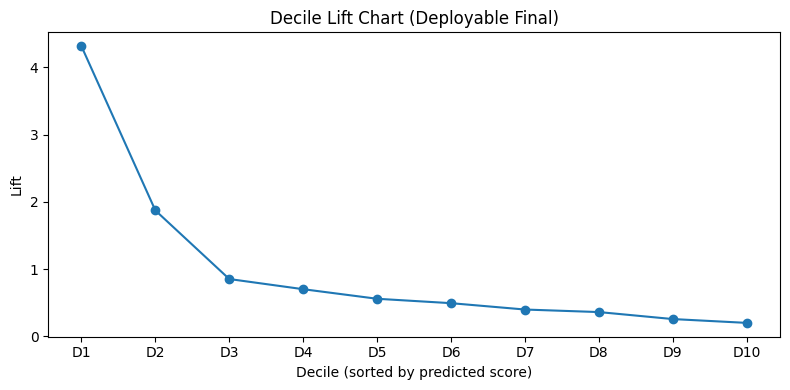


BUSINESS SCENARIO CONSTRUCTION
Business scenario:
{'BASE_SUCCESS_VALUE': 120.0, 'BALANCE_VALUE_MULTIPLIER': 0.02, 'MAX_BALANCE_FOR_VALUE': 10000.0, 'CONTACT_FRACTION': 0.15, 'K_max_contacts': 1356, 'BUDGET': 6984.029790998562, 'avg_contact_cost_test': 5.421541523830587}

CAMPAIGN POLICY HELPERS

POLICY COMPARISON ON TEST SET
Policy comparison:


,policy,n_selected,total_cost,expected_profit_using_deploy_model,realized_profit,response_rate,avg_pred_prob,ROI,optimization_status,optimization_objective_value
0,Leaky_ML_OR_Optimized,1351.00,6984.00,72818.509024,119258.360,0.532198,0.319922,17.075939,Optimal,124645.749364
1,Proposed_ML_OR_Optimized,1356.00,6984.00,91474.640732,95365.160,0.414454,0.391485,13.654805,Optimal,91474.640732
2,Greedy_ExpectedNet_Deployable,1347.00,6982.00,91320.369390,95172.700,0.416481,0.393802,13.631152,NaN,NaN
3,Top_Prob_Deployable,1340.00,6980.00,89824.205092,95132.220,0.429851,0.400122,13.629258,NaN,NaN
4,Heuristic_Rule,1342.00,6982.00,58403.537047,62615.960,0.287630,0.264817,8.968198,NaN,NaN
5,Random_Average,1288.13,6982.06,18456.755291,18457.667,0.117315,0.116286,2.643574,NaN,NaN


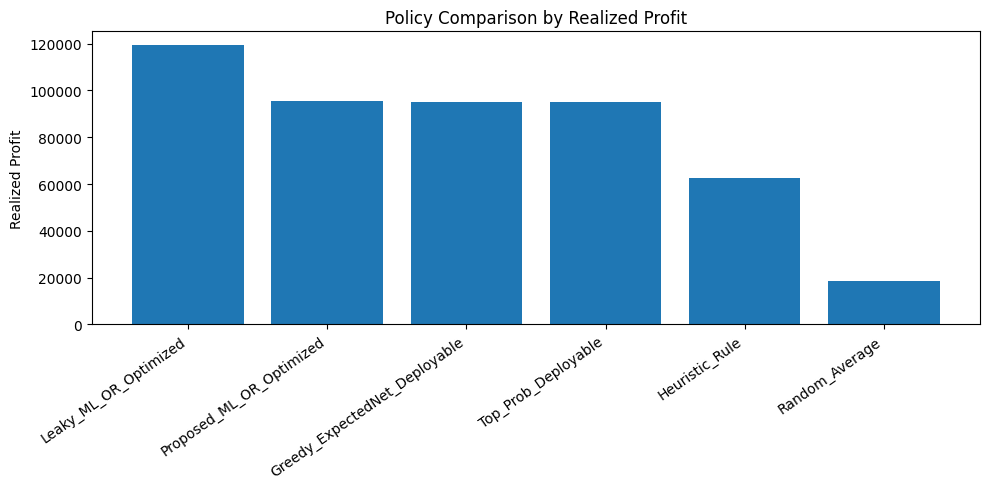

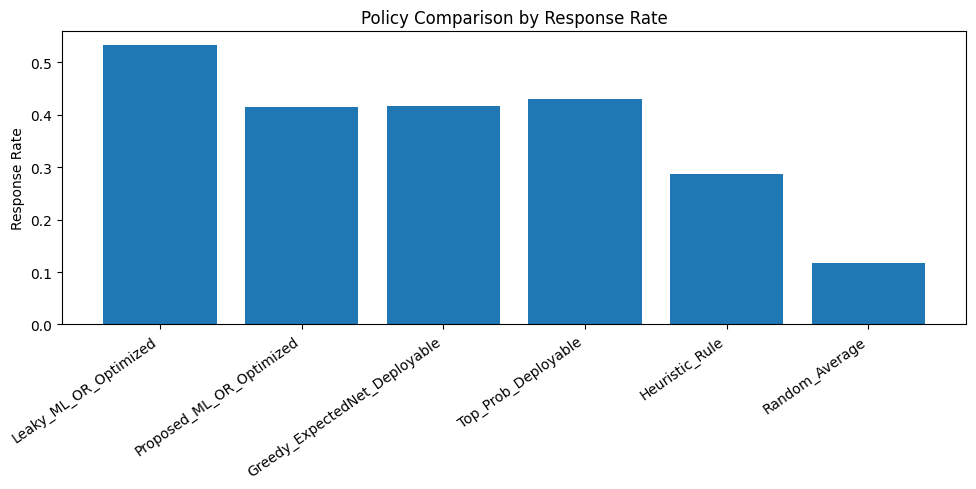


SENSITIVITY ANALYSIS OVER CONTACT FRACTIONS
Sensitivity results:


,policy,n_selected,total_cost,expected_profit_using_deploy_model,realized_profit,response_rate,avg_pred_prob,ROI,contact_fraction,optimization_status,optimization_objective_value
0,Top_Prob_Deployable,449,2327.0,46367.405878,46361.44,0.612472,0.603231,19.923266,0.05,NaN,NaN
1,Heuristic_Rule,448,2324.0,41538.239573,42325.56,0.546875,0.524532,18.212375,0.05,NaN,NaN
2,Proposed_ML_OR_Optimized,452,2327.0,49422.111448,47879.12,0.573009,0.577955,20.575471,0.05,Optimal,49422.111448
3,Top_Prob_Deployable,896,4656.0,74047.104607,75727.54,0.506696,0.483988,16.264506,0.10,NaN,NaN
4,Heuristic_Rule,892,4656.0,54622.374473,57467.44,0.382287,0.356661,12.342663,0.10,NaN,NaN
5,Proposed_ML_OR_Optimized,904,4656.0,75868.869019,78033.32,0.495575,0.474141,16.759734,0.10,Optimal,75868.869019
6,Top_Prob_Deployable,1340,6980.0,89824.205092,95132.22,0.429851,0.400122,13.629258,0.15,NaN,NaN
7,Heuristic_Rule,1342,6982.0,58403.537047,62615.96,0.287630,0.264817,8.968198,0.15,NaN,NaN
8,Proposed_ML_OR_Optimized,1356,6984.0,91474.640732,95365.16,0.414454,0.391485,13.654805,0.15,Optimal,91474.640732
9,Top_Prob_Deployable,1789,9311.0,99815.607274,104952.44,0.363331,0.340322,11.271876,0.20,NaN,NaN


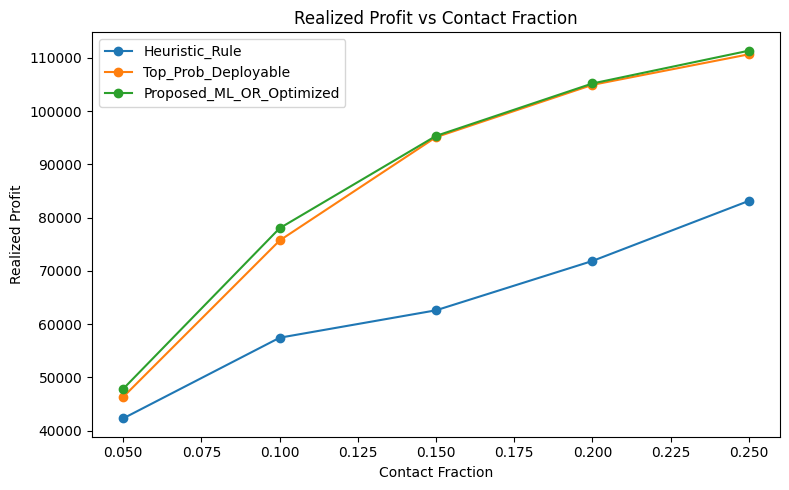


BOOTSTRAP UNCERTAINTY FOR PROPOSED POLICY REALIZED PROFIT


,policy,bootstrap_mean_profit,bootstrap_sd_profit,bootstrap_ci_2.5,bootstrap_ci_97.5
0,Proposed_ML_OR_Optimized,95253.6218,3772.712001,87951.661,103044.4965


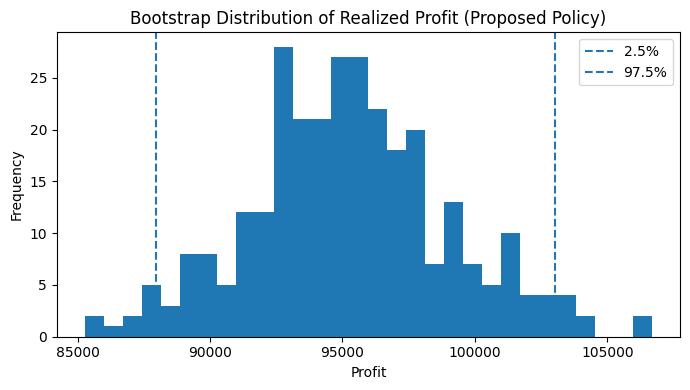


EXECUTIVE SUMMARY TABLE


,Item,Value
0,Final deployable model,RandomForest
1,Deployable test ROC-AUC,0.8003
2,Deployable test PR-AUC,0.4533
3,Deployable test F1,0.3277
4,Best leaky model,RandomForest
5,Leaky test ROC-AUC,0.9272
6,Leaky test PR-AUC,0.6142
7,Main campaign max contacts K,1356
8,Main campaign budget,6984.03
9,Best policy by realized profit,Leaky_ML_OR_Optimized



CREATING ZIP ARCHIVE
All outputs saved under: /content/bank_project_outputs_20260323_042437
ZIP archive created at: /content/bank_project_outputs_20260323_042437.zip

Files in output directory:
/content/bank_project_outputs_20260323_042437/meta
/content/bank_project_outputs_20260323_042437/meta/business_scenario.json
/content/bank_project_outputs_20260323_042437/meta/columns_after_rename.json
/content/bank_project_outputs_20260323_042437/meta/feature_sets.json
/content/bank_project_outputs_20260323_042437/meta/original_target_counts.json
/content/bank_project_outputs_20260323_042437/meta/split_info.json
/content/bank_project_outputs_20260323_042437/meta/target_mapping_info.json
/content/bank_project_outputs_20260323_042437/models
/content/bank_project_outputs_20260323_042437/models/best_deploy_base.joblib
/content/bank_project_outputs_20260323_042437/models/best_deploy_calibrated.joblib
/content/bank_project_outputs_20260323_042437/models/best_leaky_base.joblib
/content/bank_project_o

In [3]:
# ============================================================
# BANK MARKETING: PREDICTIVE + GAME-THEORETIC + OR FRAMEWORK
# Colab-ready, robust, and output-heavy pipeline
# ============================================================

# -------------------------------
# 0. Setup
# -------------------------------
import os
import re
import sys
import json
import time
import math
import shutil
import random
import warnings
import subprocess
from pathlib import Path

warnings.filterwarnings("ignore")

# Install PuLP if needed (for binary optimization / knapsack-style OR layer)
try:
    import pulp
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pulp"])
    import pulp

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss, log_loss,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import joblib

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# -------------------------------
# 1. User-configurable settings
# -------------------------------

# If your dataframe is ALREADY loaded in memory as `df`, this code will use it.
# Otherwise change FILE_PATH below to your uploaded CSV path.
FILE_PATH = "/content/bank_marketing.csv"  # change if needed

# Fraction of customers allowed to contact in constrained campaign
CONTACT_FRACTION = 0.15

# Profit scenario assumptions (purely scenario-based, for business evaluation)
BASE_SUCCESS_VALUE = 120.0          # base net value if a contacted customer subscribes
BALANCE_VALUE_MULTIPLIER = 0.02     # extra value from positive balance
MAX_BALANCE_FOR_VALUE = 10000.0     # cap balance contribution to avoid huge leverage

# Contact costs based on contact channel
CONTACT_COST_MAP = {
    "cellular": 5.0,
    "telephone": 7.0,
    "unknown": 6.0
}

# Number of random policy repetitions for benchmark
N_RANDOM_BENCHMARK_RUNS = 100

# -------------------------------
# 2. Output folder setup
# -------------------------------
timestamp = time.strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = Path(f"/content/bank_project_outputs_{timestamp}")
PLOTS_DIR = OUTPUT_DIR / "plots"
TABLES_DIR = OUTPUT_DIR / "tables"
MODELS_DIR = OUTPUT_DIR / "models"
META_DIR = OUTPUT_DIR / "meta"

for d in [OUTPUT_DIR, PLOTS_DIR, TABLES_DIR, MODELS_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def sanitize_name(s):
    s = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(s))
    s = re.sub(r"_+", "_", s).strip("_")
    return s

def save_df(df_obj, name, index=True):
    fname = TABLES_DIR / f"{sanitize_name(name)}.csv"
    df_obj.to_csv(fname, index=index)
    return fname

def save_json(obj, name):
    fname = META_DIR / f"{sanitize_name(name)}.json"
    with open(fname, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=str)
    return fname

def savefig_and_show(name, dpi=160, tight=True):
    if tight:
        plt.tight_layout()
    outpath = PLOTS_DIR / f"{sanitize_name(name)}.png"
    plt.savefig(outpath, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()

def print_header(txt):
    print("\n" + "=" * 90)
    print(txt)
    print("=" * 90)

# -------------------------------
# 3. Load data
# -------------------------------
print_header("LOADING DATA")

if "df" in globals() and isinstance(df, pd.DataFrame):
    print("Using existing dataframe `df` from notebook environment.")
    df = df.copy()
else:
    print(f"Loading data from: {FILE_PATH}")
    df = pd.read_csv(FILE_PATH, sep=None, engine="python")

print("Initial shape:", df.shape)
display(df.head())
save_df(df.head(20), "head_20_rows", index=False)

# -------------------------------
# 4. Rename V1...V16 to meaningful names if present
# -------------------------------
print_header("RENAMING COLUMNS IF NEEDED")

rename_map = {
    "V1": "age",
    "V2": "job",
    "V3": "marital",
    "V4": "education",
    "V5": "default",
    "V6": "balance",
    "V7": "housing",
    "V8": "loan",
    "V9": "contact",
    "V10": "day",
    "V11": "month",
    "V12": "duration",   # IMPORTANT: leakage-prone for pre-contact deployment
    "V13": "campaign",
    "V14": "pdays",
    "V15": "previous",
    "V16": "poutcome",
    "Class": "target"
}
present_map = {k: v for k, v in rename_map.items() if k in df.columns}
if present_map:
    df = df.rename(columns=present_map)
    print("Applied rename map:", present_map)
else:
    print("No V-style columns found; keeping existing names.")

print("Columns now:")
print(df.columns.tolist())
save_json({"columns": df.columns.tolist()}, "columns_after_rename")

# -------------------------------
# 5. Robust target handling
# -------------------------------
print_header("ROBUST TARGET MAPPING")

def coerce_binary_target(series):
    """
    Converts a 2-class target into binary 0/1.
    Priority:
    1) yes/no style labels
    2) numeric/string binary labels by assigning minority class as positive (1),
       because in Bank Marketing 'yes' is typically minority
    """
    s = series.copy()

    # preserve original for reporting
    original_counts = s.value_counts(dropna=False).to_dict()

    s_str = s.astype(str).str.strip().str.lower()
    uniq = sorted(pd.Series(s_str).dropna().unique().tolist())

    yes_aliases = {"yes", "y", "true", "1", "positive", "pos", "subscribe", "subscribed"}
    no_aliases  = {"no", "n", "false", "0", "negative", "neg", "not_subscribed"}

    # Case 1: yes/no style
    if set(uniq).issubset(yes_aliases | no_aliases) and len(uniq) == 2:
        y = s_str.isin(yes_aliases).astype(int)
        mapping_note = {
            "method": "yes/no style mapping",
            "positive_definition": "labels interpreted as yes/true/1/etc"
        }
        return y, original_counts, mapping_note

    # Case 2: general 2-class mapping by minority label -> positive
    counts = s_str.value_counts(dropna=False)
    if counts.shape[0] != 2:
        raise ValueError(
            f"Target column must have exactly 2 classes, but found {counts.shape[0]} classes: {counts.to_dict()}"
        )

    positive_label = counts.idxmin()  # minority class treated as subscriber/positive
    y = (s_str == positive_label).astype(int)
    mapping_note = {
        "method": "minority-class-as-positive mapping",
        "positive_label_assumed": positive_label,
        "reason": "Bank Marketing 'subscription=yes' is usually minority; this fixes common numeric coding issues"
    }
    return y, original_counts, mapping_note

# detect target column
target_candidates = [c for c in ["target", "y", "class", "Class", "TARGET", "Target"] if c in df.columns]
if not target_candidates:
    raise ValueError("Could not find target column. Expected something like 'Class' or 'target'.")

target_col = target_candidates[0]
df["y"] = np.nan
df["y"], original_target_counts, target_mapping_info = coerce_binary_target(df[target_col])

print("Original target counts:", original_target_counts)
print("Mapped binary target counts:", df["y"].value_counts(dropna=False).to_dict())
print("Target mapping info:", target_mapping_info)

if df["y"].nunique() != 2 or df["y"].sum() == 0:
    raise ValueError(
        "Target mapping still failed: y has only one class or all zeros. Please inspect your raw target column."
    )

save_json(original_target_counts, "original_target_counts")
save_json(target_mapping_info, "target_mapping_info")
save_df(pd.DataFrame({
    "original_label": list(pd.Series(original_target_counts).index),
    "count": list(pd.Series(original_target_counts).values)
}), "original_target_distribution", index=False)

# -------------------------------
# 6. Basic cleaning and feature engineering
# -------------------------------
print_header("BASIC CLEANING + FEATURE ENGINEERING")

# strip string columns
for c in df.select_dtypes(include=["object"]).columns:
    df[c] = df[c].astype(str).str.strip()

# numeric coercion for known numeric variables if they exist
for c in ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# feature engineering
if "pdays" in df.columns:
    df["was_previously_contacted"] = (df["pdays"].fillna(-1) != -1).astype(int)
    df["pdays_clean"] = df["pdays"].replace(-1, np.nan)

if "balance" in df.columns:
    df["balance_nonnegative"] = df["balance"].clip(lower=0)
    df["log_balance_plus1"] = np.log1p(df["balance_nonnegative"])

if "campaign" in df.columns:
    df["campaign_gt1"] = (df["campaign"].fillna(0) > 1).astype(int)

if "previous" in df.columns:
    df["previous_gt0"] = (df["previous"].fillna(0) > 0).astype(int)

print("Shape after feature engineering:", df.shape)
display(df.head())
save_df(df.head(20), "head_after_feature_engineering", index=False)

# -------------------------------
# 7. EDA: missingness, balance, summaries
# -------------------------------
print_header("EDA")

missing_df = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_pct": (100 * df.isna().mean().values).round(3)
}).sort_values(["missing_pct", "missing_count"], ascending=False)
print("Missingness summary:")
display(missing_df)
save_df(missing_df, "missingness_summary", index=False)

class_balance_df = df["y"].value_counts().rename_axis("class").reset_index(name="count")
class_balance_df["proportion"] = class_balance_df["count"] / len(df)
print("Binary target class balance:")
display(class_balance_df)
save_df(class_balance_df, "class_balance", index=False)

plt.figure(figsize=(6,4))
plt.bar(class_balance_df["class"].astype(str), class_balance_df["count"])
plt.title("Target Class Balance (0 = non-subscribe, 1 = subscribe)")
plt.xlabel("Class")
plt.ylabel("Count")
savefig_and_show("target_class_balance")

num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_all = [c for c in df.columns if c not in num_cols_all]

numeric_summary = df[num_cols_all].describe().T
display(numeric_summary)
save_df(numeric_summary, "numeric_summary")

# categorical summaries
cat_summary_rows = []
for c in cat_cols_all:
    vc = df[c].value_counts(dropna=False)
    top_label = vc.index[0]
    top_count = vc.iloc[0]
    cat_summary_rows.append({
        "column": c,
        "n_unique": df[c].nunique(dropna=False),
        "top_level": top_label,
        "top_count": top_count
    })
cat_summary = pd.DataFrame(cat_summary_rows).sort_values("n_unique", ascending=False)
display(cat_summary)
save_df(cat_summary, "categorical_summary", index=False)

# Histograms for numeric columns
plot_numeric_cols = [c for c in ["age", "balance", "duration", "campaign", "pdays", "previous"] if c in df.columns]
if plot_numeric_cols:
    n = len(plot_numeric_cols)
    ncols = 2
    nrows = math.ceil(n / ncols)
    plt.figure(figsize=(12, 4*nrows))
    for i, c in enumerate(plot_numeric_cols, 1):
        plt.subplot(nrows, ncols, i)
        vals = df[c].dropna()
        plt.hist(vals, bins=40)
        plt.title(f"Histogram: {c}")
        plt.xlabel(c)
        plt.ylabel("Frequency")
    savefig_and_show("numeric_histograms")

# Correlation heatmap for numeric cols
corr_cols = [c for c in ["age", "balance", "day", "duration", "campaign", "pdays", "previous",
                          "was_previously_contacted", "pdays_clean", "balance_nonnegative",
                          "log_balance_plus1", "campaign_gt1", "previous_gt0", "y"]
             if c in df.columns]
if len(corr_cols) >= 2:
    corr = df[corr_cols].corr(numeric_only=True)
    save_df(corr, "numeric_correlation_matrix")
    plt.figure(figsize=(10,8))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Numeric Correlation Heatmap")
    savefig_and_show("correlation_heatmap")

# target rate by selected categorical columns
def target_rate_plot(df_in, col, top_n=15):
    tmp = df_in.groupby(col)["y"].agg(["mean", "count"]).reset_index()
    tmp = tmp.sort_values("count", ascending=False).head(top_n).sort_values("mean", ascending=False)
    save_df(tmp, f"target_rate_by_{col}", index=False)
    plt.figure(figsize=(10,4))
    plt.bar(tmp[col].astype(str), tmp["mean"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Subscription Rate")
    plt.title(f"Target Rate by {col}")
    savefig_and_show(f"target_rate_by_{col}")

for c in ["job", "marital", "education", "contact", "month", "poutcome", "housing", "loan"]:
    if c in df.columns:
        target_rate_plot(df, c)

# -------------------------------
# 8. Define deployable vs leaky features
# -------------------------------
print_header("DEPLOYABLE VS LEAKY FEATURE SETS")

drop_non_features = {target_col, "y"}

# deployable = exclude duration
deployable_exclude = set(drop_non_features)
if "duration" in df.columns:
    deployable_exclude.add("duration")

X_deploy = df[[c for c in df.columns if c not in deployable_exclude]].copy()
X_leaky  = df[[c for c in df.columns if c not in drop_non_features]].copy()
y = df["y"].astype(int).copy()

print("Deployable features:", X_deploy.shape)
print("Leaky features (includes duration if present):", X_leaky.shape)

save_json({
    "deployable_columns": X_deploy.columns.tolist(),
    "leaky_columns": X_leaky.columns.tolist()
}, "feature_sets")

# -------------------------------
# 9. Consistent train/valid/test split by index
# -------------------------------
print_header("TRAIN / VALID / TEST SPLIT")

all_idx = df.index.to_numpy()

train_valid_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

train_idx, valid_idx = train_test_split(
    train_valid_idx,
    test_size=0.25,  # 0.25 of 0.80 => 0.20 overall
    random_state=SEED,
    stratify=y.loc[train_valid_idx]
)

print(f"Train size: {len(train_idx)}")
print(f"Valid size: {len(valid_idx)}")
print(f"Test size : {len(test_idx)}")

split_info = {
    "n_total": int(len(df)),
    "n_train": int(len(train_idx)),
    "n_valid": int(len(valid_idx)),
    "n_test": int(len(test_idx)),
    "positive_rate_train": float(y.loc[train_idx].mean()),
    "positive_rate_valid": float(y.loc[valid_idx].mean()),
    "positive_rate_test": float(y.loc[test_idx].mean()),
}
print(split_info)
save_json(split_info, "split_info")

# -------------------------------
# 10. Preprocessing helpers
# -------------------------------
print_header("PREPROCESSING")

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ],
        remainder="drop"
    )
    return preprocessor, numeric_cols, categorical_cols

def build_model_dict():
    return {
        "Dummy_MostFrequent": DummyClassifier(strategy="most_frequent"),
        "Logistic_L2": LogisticRegression(
            max_iter=4000,
            C=1.0,
            class_weight="balanced",
            solver="liblinear",
            random_state=SEED
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=350,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED
        ),
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=400,
            min_samples_leaf=3,
            class_weight="balanced",
            n_jobs=-1,
            random_state=SEED
        ),
    }

def build_pipeline(X, model):
    preprocessor, num_cols, cat_cols = build_preprocessor(X)
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    return pipe, num_cols, cat_cols

def choose_best_threshold(y_true, prob, metric="f1"):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_t, best_score = 0.5, -np.inf
    for t in thresholds:
        pred = (prob >= t).astype(int)
        if metric == "f1":
            score = f1_score(y_true, pred, zero_division=0)
        elif metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_true, pred)
        else:
            raise ValueError("Unknown metric for threshold selection.")
        if score > best_score:
            best_t, best_score = t, score
    return best_t, best_score

def evaluate_probs(y_true, prob, threshold=0.5, prefix=""):
    pred = (prob >= threshold).astype(int)
    out = {
        f"{prefix}Accuracy": accuracy_score(y_true, pred),
        f"{prefix}Balanced_Accuracy": balanced_accuracy_score(y_true, pred),
        f"{prefix}Precision": precision_score(y_true, pred, zero_division=0),
        f"{prefix}Recall": recall_score(y_true, pred, zero_division=0),
        f"{prefix}F1": f1_score(y_true, pred, zero_division=0),
        f"{prefix}ROC_AUC": roc_auc_score(y_true, prob),
        f"{prefix}PR_AUC": average_precision_score(y_true, prob),
        f"{prefix}Brier": brier_score_loss(y_true, prob),
        f"{prefix}LogLoss": log_loss(y_true, np.clip(prob, 1e-8, 1-1e-8)),
        f"{prefix}Threshold": threshold
    }
    return out

def make_calibrator(base_estimator):
    try:
        calib = CalibratedClassifierCV(estimator=base_estimator, method="sigmoid", cv=3)
    except TypeError:
        calib = CalibratedClassifierCV(base_estimator=base_estimator, method="sigmoid", cv=3)
    return calib

# -------------------------------
# 11. Train candidate models on deployable feature set
# -------------------------------
print_header("MODEL COMPARISON: DEPLOYABLE FEATURE SET")

X_train_dep = X_deploy.loc[train_idx].copy()
X_valid_dep = X_deploy.loc[valid_idx].copy()
X_test_dep  = X_deploy.loc[test_idx].copy()

y_train = y.loc[train_idx].copy()
y_valid = y.loc[valid_idx].copy()
y_test  = y.loc[test_idx].copy()

deploy_models = build_model_dict()

deploy_valid_rows = []
deploy_valid_probs = {}
deploy_valid_thresholds = {}
deploy_fitted_valid_models = {}

for model_name, model_obj in deploy_models.items():
    print(f"\nTraining deployable model: {model_name}")
    pipe, _, _ = build_pipeline(X_train_dep, model_obj)
    pipe.fit(X_train_dep, y_train)

    prob_valid = pipe.predict_proba(X_valid_dep)[:, 1]
    best_thr, best_thr_score = choose_best_threshold(y_valid, prob_valid, metric="f1")
    metrics = evaluate_probs(y_valid, prob_valid, threshold=best_thr, prefix="valid_")
    metrics["model"] = model_name
    metrics["best_valid_f1_at_threshold"] = best_thr_score

    deploy_valid_rows.append(metrics)
    deploy_valid_probs[model_name] = prob_valid
    deploy_valid_thresholds[model_name] = best_thr
    deploy_fitted_valid_models[model_name] = pipe

deploy_valid_results = pd.DataFrame(deploy_valid_rows).sort_values(
    ["valid_PR_AUC", "valid_ROC_AUC", "valid_Brier"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\nValidation results (deployable):")
display(deploy_valid_results)
save_df(deploy_valid_results, "deployable_validation_results", index=False)

best_deploy_model_name = deploy_valid_results.iloc[0]["model"]
best_deploy_threshold = float(deploy_valid_thresholds[best_deploy_model_name])
print(f"Best deployable model selected: {best_deploy_model_name}")
print(f"Validation-chosen threshold: {best_deploy_threshold:.3f}")

# Plot ROC curves on validation
plt.figure(figsize=(7,5))
for model_name, prob_valid in deploy_valid_probs.items():
    fpr, tpr, _ = roc_curve(y_valid, prob_valid)
    auc_val = roc_auc_score(y_valid, prob_valid)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_val:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves (Deployable Models)")
plt.legend()
savefig_and_show("validation_roc_deployable_models")

# Plot PR curves on validation
plt.figure(figsize=(7,5))
for model_name, prob_valid in deploy_valid_probs.items():
    prec, rec, _ = precision_recall_curve(y_valid, prob_valid)
    ap = average_precision_score(y_valid, prob_valid)
    plt.plot(rec, prec, label=f"{model_name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curves (Deployable Models)")
plt.legend()
savefig_and_show("validation_pr_deployable_models")

# -------------------------------
# 12. Refit best deployable model on train+valid, then calibrate, evaluate on test
# -------------------------------
print_header("FINAL DEPLOYABLE MODEL (REFIT + CALIBRATION + TEST EVALUATION)")

X_trainvalid_dep = X_deploy.loc[np.concatenate([train_idx, valid_idx])].copy()
y_trainvalid = y.loc[np.concatenate([train_idx, valid_idx])].copy()

best_deploy_model_obj = build_model_dict()[best_deploy_model_name]
best_deploy_base, _, _ = build_pipeline(X_trainvalid_dep, best_deploy_model_obj)
best_deploy_base.fit(X_trainvalid_dep, y_trainvalid)

# save uncalibrated base
joblib.dump(best_deploy_base, MODELS_DIR / "best_deploy_base.joblib")

# calibrated model
best_deploy_calibrated = make_calibrator(best_deploy_base)
best_deploy_calibrated.fit(X_trainvalid_dep, y_trainvalid)
joblib.dump(best_deploy_calibrated, MODELS_DIR / "best_deploy_calibrated.joblib")

test_prob_deploy = best_deploy_calibrated.predict_proba(X_test_dep)[:, 1]
test_metrics_deploy = evaluate_probs(y_test, test_prob_deploy, threshold=best_deploy_threshold, prefix="test_")
test_metrics_deploy["model"] = best_deploy_model_name

print("Test metrics for final deployable model:")
display(pd.DataFrame([test_metrics_deploy]))
save_df(pd.DataFrame([test_metrics_deploy]), "final_deployable_test_metrics", index=False)

# calibration plot
prob_true, prob_pred = calibration_curve(y_test, test_prob_deploy, n_bins=10, strategy="quantile")
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker="o", label="Deployable calibrated")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraction Positive")
plt.title("Calibration Curve (Test Set)")
plt.legend()
savefig_and_show("test_calibration_curve_deployable")

# confusion matrix
test_pred_deploy = (test_prob_deploy >= best_deploy_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred_deploy)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix (Deployable Final, threshold={best_deploy_threshold:.2f})")
savefig_and_show("test_confusion_matrix_deployable")

# -------------------------------
# 13. Leaky benchmark (includes duration) for comparison
# -------------------------------
print_header("LEAKY BENCHMARK (INCLUDES DURATION)")

X_train_leak = X_leaky.loc[train_idx].copy()
X_valid_leak = X_leaky.loc[valid_idx].copy()
X_test_leak  = X_leaky.loc[test_idx].copy()
X_trainvalid_leak = X_leaky.loc[np.concatenate([train_idx, valid_idx])].copy()

leaky_models = build_model_dict()
leaky_valid_rows = []
leaky_valid_probs = {}
leaky_valid_thresholds = {}

for model_name, model_obj in leaky_models.items():
    print(f"\nTraining leaky model: {model_name}")
    pipe, _, _ = build_pipeline(X_train_leak, model_obj)
    pipe.fit(X_train_leak, y_train)

    prob_valid = pipe.predict_proba(X_valid_leak)[:, 1]
    best_thr, best_thr_score = choose_best_threshold(y_valid, prob_valid, metric="f1")
    metrics = evaluate_probs(y_valid, prob_valid, threshold=best_thr, prefix="valid_")
    metrics["model"] = model_name
    metrics["best_valid_f1_at_threshold"] = best_thr_score

    leaky_valid_rows.append(metrics)
    leaky_valid_probs[model_name] = prob_valid
    leaky_valid_thresholds[model_name] = best_thr

leaky_valid_results = pd.DataFrame(leaky_valid_rows).sort_values(
    ["valid_PR_AUC", "valid_ROC_AUC", "valid_Brier"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("Validation results (leaky benchmark):")
display(leaky_valid_results)
save_df(leaky_valid_results, "leaky_validation_results", index=False)

best_leaky_model_name = leaky_valid_results.iloc[0]["model"]
best_leaky_threshold = float(leaky_valid_thresholds[best_leaky_model_name])

print(f"Best leaky model selected: {best_leaky_model_name}")
print(f"Validation-chosen threshold (leaky): {best_leaky_threshold:.3f}")

best_leaky_model_obj = build_model_dict()[best_leaky_model_name]
best_leaky_base, _, _ = build_pipeline(X_trainvalid_leak, best_leaky_model_obj)
best_leaky_base.fit(X_trainvalid_leak, y_trainvalid)
joblib.dump(best_leaky_base, MODELS_DIR / "best_leaky_base.joblib")

best_leaky_calibrated = make_calibrator(best_leaky_base)
best_leaky_calibrated.fit(X_trainvalid_leak, y_trainvalid)
joblib.dump(best_leaky_calibrated, MODELS_DIR / "best_leaky_calibrated.joblib")

test_prob_leaky = best_leaky_calibrated.predict_proba(X_test_leak)[:, 1]
test_metrics_leaky = evaluate_probs(y_test, test_prob_leaky, threshold=best_leaky_threshold, prefix="test_")
test_metrics_leaky["model"] = best_leaky_model_name

comparison_test_metrics = pd.DataFrame([
    {"setting": "deployable_no_duration", **test_metrics_deploy},
    {"setting": "leaky_with_duration", **test_metrics_leaky}
])
print("Deployable vs leaky test comparison:")
display(comparison_test_metrics)
save_df(comparison_test_metrics, "deployable_vs_leaky_test_comparison", index=False)

# ROC comparison
plt.figure(figsize=(7,5))
for label, prob in [("Deployable", test_prob_deploy), ("Leaky", test_prob_leaky)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_val:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC: Deployable vs Leaky")
plt.legend()
savefig_and_show("test_roc_deployable_vs_leaky")

# PR comparison
plt.figure(figsize=(7,5))
for label, prob in [("Deployable", test_prob_deploy), ("Leaky", test_prob_leaky)]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(rec, prec, label=f"{label} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test PR Curve: Deployable vs Leaky")
plt.legend()
savefig_and_show("test_pr_deployable_vs_leaky")

# -------------------------------
# 14. Interpretability: coefficients / feature importance
# -------------------------------
print_header("INTERPRETABILITY FOR FINAL DEPLOYABLE MODEL")

def get_feature_names_from_pipeline(fitted_pipeline):
    pre = fitted_pipeline.named_steps["preprocess"]
    return pre.get_feature_names_out()

feature_names = get_feature_names_from_pipeline(best_deploy_base)
model_core = best_deploy_base.named_steps["model"]

if hasattr(model_core, "coef_"):
    coef_series = pd.Series(model_core.coef_.ravel(), index=feature_names).sort_values(key=np.abs, ascending=False)
    coef_df = coef_series.reset_index()
    coef_df.columns = ["feature", "coefficient"]
    display(coef_df.head(25))
    save_df(coef_df, "deployable_top_coefficients", index=False)

    top_coef = coef_series.head(20).sort_values()
    plt.figure(figsize=(8,7))
    plt.barh(top_coef.index, top_coef.values)
    plt.title("Top 20 Logistic Coefficients (Deployable Final)")
    plt.xlabel("Coefficient")
    savefig_and_show("top_logistic_coefficients_deployable")

elif hasattr(model_core, "feature_importances_"):
    imp_series = pd.Series(model_core.feature_importances_, index=feature_names).sort_values(ascending=False)
    imp_df = imp_series.reset_index()
    imp_df.columns = ["feature", "importance"]
    display(imp_df.head(25))
    save_df(imp_df, "deployable_feature_importances", index=False)

    top_imp = imp_series.head(20).sort_values()
    plt.figure(figsize=(8,7))
    plt.barh(top_imp.index, top_imp.values)
    plt.title("Top 20 Feature Importances (Deployable Final)")
    plt.xlabel("Importance")
    savefig_and_show("top_feature_importances_deployable")

else:
    print("Model does not expose coefficients or feature importances directly.")

# -------------------------------
# 15. Lift / gain style evaluation
# -------------------------------
print_header("LIFT / DECILE ANALYSIS")

def make_decile_lift_table(y_true, prob, n_groups=10):
    temp = pd.DataFrame({"y": np.array(y_true), "prob": np.array(prob)})
    temp = temp.sort_values("prob", ascending=False).reset_index(drop=True)
    temp["rank"] = np.arange(1, len(temp) + 1)

    # create equal-sized rank groups
    temp["decile"] = pd.qcut(temp["rank"], q=n_groups, labels=[f"D{i}" for i in range(1, n_groups+1)])
    # D1 is lowest by qcut on rank, but we sorted descending, so fix order later
    # Better reorder manually:
    decile_summary = temp.groupby("decile").agg(
        n=("y", "size"),
        responders=("y", "sum"),
        avg_score=("prob", "mean"),
        response_rate=("y", "mean")
    ).reset_index()

    # reorder so top decile = highest score group
    decile_summary["decile_num"] = range(1, len(decile_summary)+1)
    decile_summary = decile_summary.sort_values("decile_num").copy()
    overall_rate = temp["y"].mean()
    decile_summary["lift"] = decile_summary["response_rate"] / max(overall_rate, 1e-12)
    decile_summary["cum_responders"] = decile_summary["responders"].cumsum()
    decile_summary["cum_response_share"] = decile_summary["cum_responders"] / max(temp["y"].sum(), 1)
    decile_summary.drop(columns=["decile_num"], inplace=True)
    return decile_summary

lift_deploy = make_decile_lift_table(y_test, test_prob_deploy, n_groups=10)
display(lift_deploy)
save_df(lift_deploy, "decile_lift_deployable", index=False)

plt.figure(figsize=(8,4))
plt.plot(range(1, len(lift_deploy)+1), lift_deploy["lift"], marker="o")
plt.xticks(range(1, len(lift_deploy)+1), lift_deploy["decile"])
plt.xlabel("Decile (sorted by predicted score)")
plt.ylabel("Lift")
plt.title("Decile Lift Chart (Deployable Final)")
savefig_and_show("decile_lift_chart_deployable")

# -------------------------------
# 16. Business scenario construction
# -------------------------------
print_header("BUSINESS SCENARIO CONSTRUCTION")

test_raw = df.loc[test_idx].copy()
test_raw["pred_prob_deploy"] = test_prob_deploy
test_raw["pred_prob_leaky"] = test_prob_leaky

# contact cost
if "contact" in test_raw.columns:
    test_raw["contact_cost"] = (
        test_raw["contact"].astype(str).str.lower().map(CONTACT_COST_MAP).fillna(6.0)
    )
else:
    test_raw["contact_cost"] = 6.0

# customer value if success (scenario-based)
if "balance" in test_raw.columns:
    bal = test_raw["balance"].clip(lower=0, upper=MAX_BALANCE_FOR_VALUE)
else:
    bal = pd.Series(0.0, index=test_raw.index)

test_raw["value_if_success"] = BASE_SUCCESS_VALUE + BALANCE_VALUE_MULTIPLIER * bal

# slight premiums for presumably easier/cheaper-to-convert profiles (scenario-based, pre-contact features only)
if "loan" in test_raw.columns:
    test_raw["value_if_success"] += 10.0 * (test_raw["loan"].astype(str).str.lower() == "no").astype(float)
if "housing" in test_raw.columns:
    test_raw["value_if_success"] += 8.0 * (test_raw["housing"].astype(str).str.lower() == "no").astype(float)
if "previous" in test_raw.columns:
    test_raw["value_if_success"] += 5.0 * (test_raw["previous"].fillna(0) > 0).astype(float)

test_raw["expected_net_deploy"] = test_raw["pred_prob_deploy"] * test_raw["value_if_success"] - test_raw["contact_cost"]
test_raw["expected_net_leaky"] = test_raw["pred_prob_leaky"] * test_raw["value_if_success"] - test_raw["contact_cost"]
test_raw["realized_value"] = test_raw["y"] * test_raw["value_if_success"]

# heuristic score (deliberately simple benchmark)
heuristic = pd.Series(0.0, index=test_raw.index)

if "previous" in test_raw.columns:
    heuristic += 1.5 * (test_raw["previous"].fillna(0) > 0).astype(float)
if "poutcome" in test_raw.columns:
    heuristic += 2.0 * (test_raw["poutcome"].astype(str).str.lower() == "success").astype(float)
if "housing" in test_raw.columns:
    heuristic += 0.75 * (test_raw["housing"].astype(str).str.lower() == "no").astype(float)
if "loan" in test_raw.columns:
    heuristic += 0.75 * (test_raw["loan"].astype(str).str.lower() == "no").astype(float)
if "balance" in test_raw.columns:
    bal_norm = test_raw["balance"].clip(lower=test_raw["balance"].quantile(0.01),
                                        upper=test_raw["balance"].quantile(0.99))
    bal_norm = (bal_norm - bal_norm.min()) / (bal_norm.max() - bal_norm.min() + 1e-9)
    heuristic += bal_norm

test_raw["heuristic_score"] = heuristic

# campaign constraints
N_TEST = len(test_raw)
K = max(1, int(CONTACT_FRACTION * N_TEST))
avg_cost = float(test_raw["contact_cost"].mean())
BUDGET = 0.95 * avg_cost * K   # slight budget pressure so both K and budget matter

scenario_info = {
    "BASE_SUCCESS_VALUE": BASE_SUCCESS_VALUE,
    "BALANCE_VALUE_MULTIPLIER": BALANCE_VALUE_MULTIPLIER,
    "MAX_BALANCE_FOR_VALUE": MAX_BALANCE_FOR_VALUE,
    "CONTACT_FRACTION": CONTACT_FRACTION,
    "K_max_contacts": K,
    "BUDGET": BUDGET,
    "avg_contact_cost_test": avg_cost
}
print("Business scenario:")
print(scenario_info)
save_json(scenario_info, "business_scenario")
save_df(test_raw.head(50), "test_raw_with_business_fields", index=False)

# -------------------------------
# 17. Campaign selection helpers
# -------------------------------
print_header("CAMPAIGN POLICY HELPERS")

def evaluate_selection(df_in, selected_idx, label):
    sel = df_in.loc[selected_idx].copy()
    n_selected = len(sel)
    total_cost = float(sel["contact_cost"].sum())
    expected_profit = float((sel["pred_prob_deploy"] * sel["value_if_success"] - sel["contact_cost"]).sum())
    realized_profit = float((sel["realized_value"] - sel["contact_cost"]).sum())
    response_rate = float(sel["y"].mean()) if n_selected > 0 else 0.0
    avg_prob = float(sel["pred_prob_deploy"].mean()) if n_selected > 0 else 0.0
    roi = realized_profit / total_cost if total_cost > 0 else np.nan

    return {
        "policy": label,
        "n_selected": n_selected,
        "total_cost": total_cost,
        "expected_profit_using_deploy_model": expected_profit,
        "realized_profit": realized_profit,
        "response_rate": response_rate,
        "avg_pred_prob": avg_prob,
        "ROI": roi
    }

def greedy_select_by_score(df_in, score_col, budget, k_max, ascending=False):
    order = df_in.sort_values(score_col, ascending=ascending).index.tolist()
    selected = []
    running_cost = 0.0
    for idx in order:
        c = float(df_in.at[idx, "contact_cost"])
        if len(selected) < k_max and running_cost + c <= budget:
            selected.append(idx)
            running_cost += c
    return selected

def random_feasible_selection(df_in, budget, k_max, rng):
    order = list(df_in.index)
    rng.shuffle(order)
    selected = []
    running_cost = 0.0
    for idx in order:
        c = float(df_in.at[idx, "contact_cost"])
        if len(selected) < k_max and running_cost + c <= budget:
            selected.append(idx)
            running_cost += c
    return selected

def optimize_campaign_pulp(df_in, objective_col, budget, k_max):
    prob = pulp.LpProblem("BankMarketingCampaignOptimization", pulp.LpMaximize)
    idxs = list(df_in.index)
    z = {i: pulp.LpVariable(f"z_{i}", lowBound=0, upBound=1, cat="Binary") for i in idxs}

    prob += pulp.lpSum(float(df_in.at[i, objective_col]) * z[i] for i in idxs)
    prob += pulp.lpSum(float(df_in.at[i, "contact_cost"]) * z[i] for i in idxs) <= budget
    prob += pulp.lpSum(z[i] for i in idxs) <= k_max

    solver = pulp.PULP_CBC_CMD(msg=False)
    status = prob.solve(solver)

    selected = [i for i in idxs if pulp.value(z[i]) is not None and pulp.value(z[i]) > 0.5]
    status_str = pulp.LpStatus[status]
    objective_value = pulp.value(prob.objective)

    return selected, status_str, objective_value

# -------------------------------
# 18. Policy comparison on test set
# -------------------------------
print_header("POLICY COMPARISON ON TEST SET")

policy_rows = []

# 1) Random benchmark (average over many runs)
rng = random.Random(SEED)
random_metrics = []
for r in range(N_RANDOM_BENCHMARK_RUNS):
    sel = random_feasible_selection(test_raw, BUDGET, K, rng)
    random_metrics.append(evaluate_selection(test_raw, sel, label="Random"))
random_df = pd.DataFrame(random_metrics)
random_summary = {
    "policy": "Random_Average",
    "n_selected": random_df["n_selected"].mean(),
    "total_cost": random_df["total_cost"].mean(),
    "expected_profit_using_deploy_model": random_df["expected_profit_using_deploy_model"].mean(),
    "realized_profit": random_df["realized_profit"].mean(),
    "response_rate": random_df["response_rate"].mean(),
    "avg_pred_prob": random_df["avg_pred_prob"].mean(),
    "ROI": random_df["ROI"].mean()
}
policy_rows.append(random_summary)

# 2) Simple heuristic benchmark
sel_heur = greedy_select_by_score(test_raw, "heuristic_score", BUDGET, K, ascending=False)
policy_rows.append(evaluate_selection(test_raw, sel_heur, "Heuristic_Rule"))

# 3) Top-K by deployable predicted probability
sel_top_prob = greedy_select_by_score(test_raw, "pred_prob_deploy", BUDGET, K, ascending=False)
policy_rows.append(evaluate_selection(test_raw, sel_top_prob, "Top_Prob_Deployable"))

# 4) Greedy by expected net value (not full MILP, still stronger than pure score)
sel_top_expected = greedy_select_by_score(test_raw, "expected_net_deploy", BUDGET, K, ascending=False)
policy_rows.append(evaluate_selection(test_raw, sel_top_expected, "Greedy_ExpectedNet_Deployable"))

# 5) Proposed methodology: deployable ML + OR optimization
sel_opt, opt_status, opt_obj = optimize_campaign_pulp(
    test_raw,
    objective_col="expected_net_deploy",
    budget=BUDGET,
    k_max=K
)
row_opt = evaluate_selection(test_raw, sel_opt, "Proposed_ML_OR_Optimized")
row_opt["optimization_status"] = opt_status
row_opt["optimization_objective_value"] = opt_obj
policy_rows.append(row_opt)

# 6) Leaky optimized policy (to illustrate overly optimistic decisioning if duration is used)
sel_opt_leaky, opt_status_leaky, opt_obj_leaky = optimize_campaign_pulp(
    test_raw.assign(expected_net_leaky=test_raw["expected_net_leaky"]),
    objective_col="expected_net_leaky",
    budget=BUDGET,
    k_max=K
)
row_opt_leaky = evaluate_selection(test_raw, sel_opt_leaky, "Leaky_ML_OR_Optimized")
row_opt_leaky["optimization_status"] = opt_status_leaky
row_opt_leaky["optimization_objective_value"] = opt_obj_leaky
policy_rows.append(row_opt_leaky)

policy_comparison = pd.DataFrame(policy_rows).sort_values("realized_profit", ascending=False).reset_index(drop=True)
print("Policy comparison:")
display(policy_comparison)
save_df(policy_comparison, "policy_comparison_test", index=False)

# Plot realized profit comparison
plt.figure(figsize=(10,5))
plt.bar(policy_comparison["policy"], policy_comparison["realized_profit"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Realized Profit")
plt.title("Policy Comparison by Realized Profit")
savefig_and_show("policy_comparison_realized_profit")

# Plot response rate comparison
plt.figure(figsize=(10,5))
plt.bar(policy_comparison["policy"], policy_comparison["response_rate"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Response Rate")
plt.title("Policy Comparison by Response Rate")
savefig_and_show("policy_comparison_response_rate")

# Save selected customer lists
for name, sel in [
    ("heuristic_selected_customers", sel_heur),
    ("top_prob_selected_customers", sel_top_prob),
    ("greedy_expected_selected_customers", sel_top_expected),
    ("optimized_selected_customers", sel_opt),
    ("leaky_optimized_selected_customers", sel_opt_leaky),
]:
    save_df(test_raw.loc[sel], name)

# -------------------------------
# 19. Budget/contact-fraction sensitivity analysis
# -------------------------------
print_header("SENSITIVITY ANALYSIS OVER CONTACT FRACTIONS")

fractions = [0.05, 0.10, 0.15, 0.20, 0.25]
sens_rows = []

for frac in fractions:
    k_frac = max(1, int(frac * len(test_raw)))
    budget_frac = 0.95 * avg_cost * k_frac

    # top probability
    sel_top_prob_f = greedy_select_by_score(test_raw, "pred_prob_deploy", budget_frac, k_frac, ascending=False)
    res_top_prob_f = evaluate_selection(test_raw, sel_top_prob_f, "Top_Prob_Deployable")
    res_top_prob_f["contact_fraction"] = frac
    sens_rows.append(res_top_prob_f)

    # heuristic
    sel_heur_f = greedy_select_by_score(test_raw, "heuristic_score", budget_frac, k_frac, ascending=False)
    res_heur_f = evaluate_selection(test_raw, sel_heur_f, "Heuristic_Rule")
    res_heur_f["contact_fraction"] = frac
    sens_rows.append(res_heur_f)

    # optimized
    sel_opt_f, st_f, obj_f = optimize_campaign_pulp(test_raw, "expected_net_deploy", budget_frac, k_frac)
    res_opt_f = evaluate_selection(test_raw, sel_opt_f, "Proposed_ML_OR_Optimized")
    res_opt_f["contact_fraction"] = frac
    res_opt_f["optimization_status"] = st_f
    res_opt_f["optimization_objective_value"] = obj_f
    sens_rows.append(res_opt_f)

sensitivity_df = pd.DataFrame(sens_rows)
print("Sensitivity results:")
display(sensitivity_df.head(20))
save_df(sensitivity_df, "sensitivity_analysis_contact_fraction", index=False)

# Plot realized profit vs contact fraction
plt.figure(figsize=(8,5))
for policy_name in ["Heuristic_Rule", "Top_Prob_Deployable", "Proposed_ML_OR_Optimized"]:
    tmp = sensitivity_df[sensitivity_df["policy"] == policy_name].sort_values("contact_fraction")
    plt.plot(tmp["contact_fraction"], tmp["realized_profit"], marker="o", label=policy_name)
plt.xlabel("Contact Fraction")
plt.ylabel("Realized Profit")
plt.title("Realized Profit vs Contact Fraction")
plt.legend()
savefig_and_show("sensitivity_realized_profit_vs_contact_fraction")

# -------------------------------
# 20. Optional bootstrap uncertainty for proposed policy profit
# -------------------------------
print_header("BOOTSTRAP UNCERTAINTY FOR PROPOSED POLICY REALIZED PROFIT")

# Use the selected optimized policy from the main scenario
opt_sel_df = test_raw.loc[sel_opt].copy()

bootstrap_profits = []
rng_np = np.random.default_rng(SEED)

if len(opt_sel_df) > 0:
    for b in range(300):
        samp = opt_sel_df.sample(n=len(opt_sel_df), replace=True, random_state=int(rng_np.integers(0, 10**9)))
        boot_profit = float((samp["realized_value"] - samp["contact_cost"]).sum())
        bootstrap_profits.append(boot_profit)

    boot_arr = np.array(bootstrap_profits)
    boot_summary = pd.DataFrame([{
        "policy": "Proposed_ML_OR_Optimized",
        "bootstrap_mean_profit": float(np.mean(boot_arr)),
        "bootstrap_sd_profit": float(np.std(boot_arr, ddof=1)),
        "bootstrap_ci_2.5": float(np.percentile(boot_arr, 2.5)),
        "bootstrap_ci_97.5": float(np.percentile(boot_arr, 97.5))
    }])
    display(boot_summary)
    save_df(boot_summary, "bootstrap_profit_summary", index=False)

    plt.figure(figsize=(7,4))
    plt.hist(boot_arr, bins=30)
    plt.axvline(np.percentile(boot_arr, 2.5), linestyle="--", label="2.5%")
    plt.axvline(np.percentile(boot_arr, 97.5), linestyle="--", label="97.5%")
    plt.title("Bootstrap Distribution of Realized Profit (Proposed Policy)")
    plt.xlabel("Profit")
    plt.ylabel("Frequency")
    plt.legend()
    savefig_and_show("bootstrap_profit_distribution_proposed")
else:
    print("No customers selected under proposed policy; bootstrap skipped.")

# -------------------------------
# 21. Compact executive summary table
# -------------------------------
print_header("EXECUTIVE SUMMARY TABLE")

executive_summary = pd.DataFrame({
    "Item": [
        "Final deployable model",
        "Deployable test ROC-AUC",
        "Deployable test PR-AUC",
        "Deployable test F1",
        "Best leaky model",
        "Leaky test ROC-AUC",
        "Leaky test PR-AUC",
        "Main campaign max contacts K",
        "Main campaign budget",
        "Best policy by realized profit"
    ],
    "Value": [
        best_deploy_model_name,
        round(test_metrics_deploy["test_ROC_AUC"], 4),
        round(test_metrics_deploy["test_PR_AUC"], 4),
        round(test_metrics_deploy["test_F1"], 4),
        best_leaky_model_name,
        round(test_metrics_leaky["test_ROC_AUC"], 4),
        round(test_metrics_leaky["test_PR_AUC"], 4),
        K,
        round(BUDGET, 2),
        policy_comparison.iloc[0]["policy"]
    ]
})
display(executive_summary)
save_df(executive_summary, "executive_summary", index=False)

# -------------------------------
# 22. Zip outputs
# -------------------------------
print_header("CREATING ZIP ARCHIVE")

zip_base = str(OUTPUT_DIR)
zip_path = shutil.make_archive(zip_base, "zip", root_dir=OUTPUT_DIR)

print(f"All outputs saved under: {OUTPUT_DIR}")
print(f"ZIP archive created at: {zip_path}")

# Optional: display quick listing
print("\nFiles in output directory:")
for p in sorted(OUTPUT_DIR.rglob("*")):
    print(p)